In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from smooth_POD_ROM.post_processing import richardson_lucy, post_process
from smooth_POD_ROM.initial_conditions import rectangular_pulse, small_r_pulse
from smooth_POD_ROM.post_processing import get_sigma, richardson_lucy
from smooth_POD_ROM.reduced_order_model import make_training_data, get_data_rw, L2_error_rw,target_function, snapshots_rowwise, optimize_sROM

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.5

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"
#pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/"
#pth = "/home/florianma@ad.ife.no/matpro_files/Florian/results/sPODROM/"
markevery = 100

8.030570172000001


In [3]:
def initial_condition(x, mu):
    return rectangular_pulse(x, mu, w=0.02 + 1e-6)

In [4]:
n_x = 500
x = np.linspace(0, 1, n_x, endpoint=False)

n_test =  50
mu_test = np.linspace(0, 1, n_test)[:, None]

case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "mu_test": mu_test,
    "g": initial_condition, # initial_condition, small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "mode": "wrap",
    "sigma": 0.06,

    "c": 2,
    "monitor_progress_postprocessing": False,
    "num_iter": 250,
    "monitor_convergence": False,
    "sROM_only": False,
    "sigmaD": "calc_based_on_distance",
}

In [5]:
N_max = 150 # max rank
n_trials = 5
_sima_ = 0.016
_sima2_ = 0.032
c = 2

case["sigma"] = _sima_
X_test, X_test_s1 = get_data_rw(mu_test, **case)
case["sigma"] = _sima2_
X_test, X_test_s2 = get_data_rw(mu_test, **case)

10.0 9.999999999999998 10.000000000000002
10.0 10.0 9.999999999999998


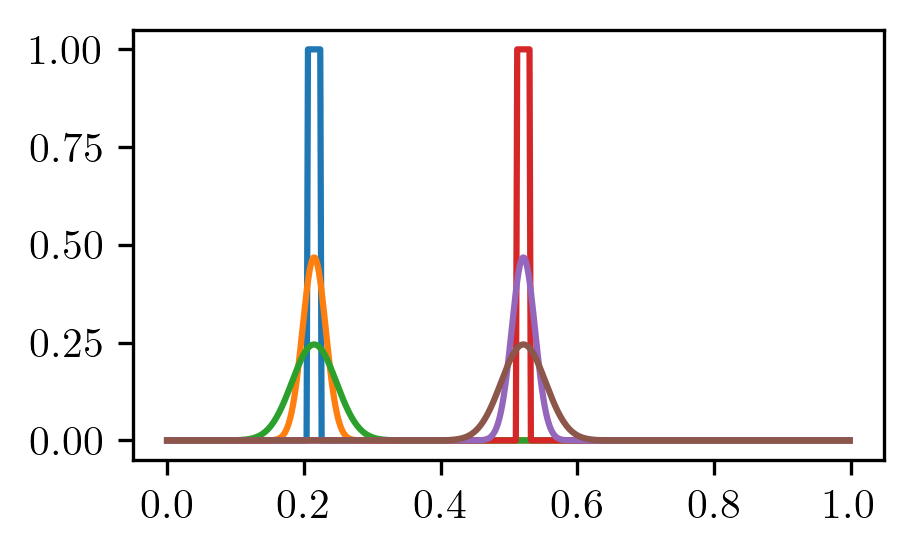

In [6]:

for i in [10, 25]:
    print(np.sum(X_test[i]), np.sum(X_test_s1[i]), np.sum(X_test_s2[i]))
    plt.plot(x, X_test[i])
    plt.plot(x, X_test_s1[i])
    plt.plot(x, X_test_s2[i])
plt.show()

In [7]:


NN = np.arange(1, N_max, 1)
e_conventional = np.zeros((len(NN), n_trials))
e_smooth1 = np.zeros((len(NN), n_trials))-1
e_smooth2 = np.zeros((len(NN), n_trials))-1
e_desmoothed1 = np.zeros((len(NN), n_trials))-1
e_desmoothed2 = np.zeros((len(NN), n_trials))-1

for i, n in enumerate(NN):
    for trial in range(n_trials):
        mu_train = np.random.rand(n)[:, None]
        case["sigma"] = _sima_
        basis1, basis2 = get_data_rw(mu_train, **case)
        case["sigma"] = _sima2_
        _, basis3 = get_data_rw(mu_train, **case)

        
        coefficients1, _, _, _ = np.linalg.lstsq(basis1.T, X_test.T, rcond=None)  # solves a@x=b given a and b
        coefficients2, _, _, _ = np.linalg.lstsq(basis2.T, X_test_s1.T, rcond=None)  # solves a@x=b given a and b
        coefficients3, _, _, _ = np.linalg.lstsq(basis3.T, X_test_s2.T, rcond=None)  # solves a@x=b given a and b
        approximations1 = (basis1.T @ coefficients1).T  # same as X_test_ROM?
        approximations2 = (basis2.T @ coefficients2).T  # same as X_test_sROM?
        approximations3 = (basis3.T @ coefficients3).T  # same as X_test_sROM?


        approximations2DS = np.empty_like(approximations2)
        approximations3DS = np.empty_like(approximations3)
        for j in range(len(mu_test)):
            sgm_est = get_sigma(_sima_, mu_test[j][None, ...], mu_train, c=c)
            approximations2DS[j] = richardson_lucy(x, approximations2[j], sgm_est, num_iter=200, monitor_convergence=False).reshape(approximations2DS[j].shape)
            sgm_est = get_sigma(_sima2_, mu_test[j][None, ...], mu_train, c=c)
            approximations3DS[j] = richardson_lucy(x, approximations3[j], sgm_est, num_iter=200, monitor_convergence=False).reshape(approximations3DS[j].shape)
            
        e_conventional[i, trial] = np.mean(L2_error_rw(approximations1, X_test))
        e_smooth1[i, trial] = np.mean(L2_error_rw(approximations2, X_test))
        e_smooth2[i, trial] = np.mean(L2_error_rw(approximations3, X_test))
        e_desmoothed1[i, trial] = np.mean(L2_error_rw(approximations2DS, X_test))
        e_desmoothed2[i, trial] = np.mean(L2_error_rw(approximations3DS, X_test))

    print(n, np.median(e_conventional[i, :]), np.median(e_desmoothed1[i, :]),  np.median(e_desmoothed2[i, :]))

np.save(pth+"/NN.npy", NN)
np.save(pth+"/e_conventional.npy", e_conventional)
np.save(pth+"/e_smooth1.npy", e_smooth1)
np.save(pth+"/e_smooth2.npy", e_smooth2)
np.save(pth+"/e_desmoothed1.npy", e_desmoothed1)
np.save(pth+"/e_desmoothed2.npy", e_desmoothed2)

C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


1 0.14089564450716133 0.14233565286178887 0.14314434851388821
2 0.13970712782462688 0.14270192570276896 0.14572470606561352
3 0.13848410624382454 0.14338403174243666 0.14597116196351886
4 0.1380826077483687 0.14426384286210436 0.13815129114632094
5 0.1358159193721341 0.13627579599583764 0.13250122130077271
6 0.134908694728055 0.1355139500074979 0.13572366801202126
7 0.13354503368430198 0.13707531993948568 0.13237426197259056
8 0.1315796217081993 0.12743607615113803 0.11533052830373125
9 0.1312276824828372 0.13079806835246907 0.1170388898162085
10 0.12865019956982943 0.12631809093409563 0.11396233069446587
11 0.12863672816893082 0.12105138978045417 0.10222325226670144
12 0.1283481039813754 0.11732224953903189 0.09947892457046435
13 0.12569882439759253 0.11546116573280331 0.09842836468302923
14 0.12563988761366088 0.11408507278925667 0.09025519058016744
15 0.1252239526933318 0.10990710258543464 0.08401530148990441
16 0.12145399895669412 0.10539486845902594 0.0816585241423385
17 0.1223795

In [8]:
NN = np.load(pth+"/NN.npy")
e_conventional = np.load(pth+"/e_conventional.npy")
e_smooth1 = np.load(pth+"/e_smooth1.npy")
e_smooth2 = np.load(pth+"/e_smooth2.npy")
e_desmoothed1 = np.load(pth+"/e_desmoothed1.npy")
e_desmoothed2 = np.load(pth+"/e_desmoothed2.npy")

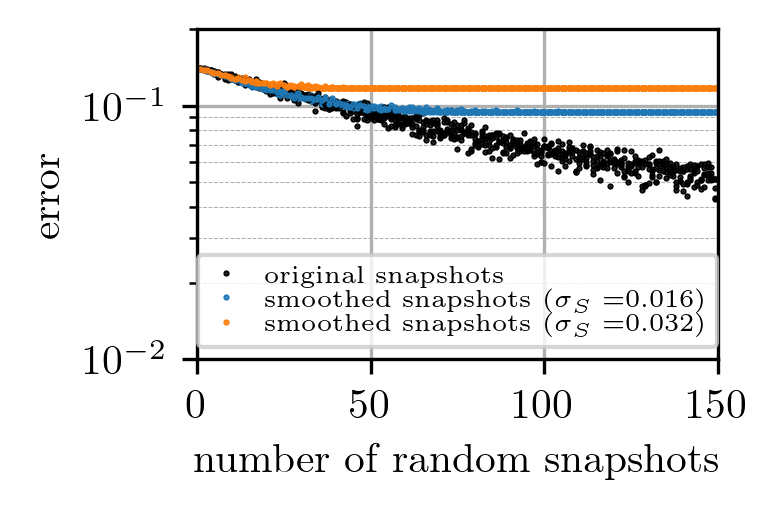

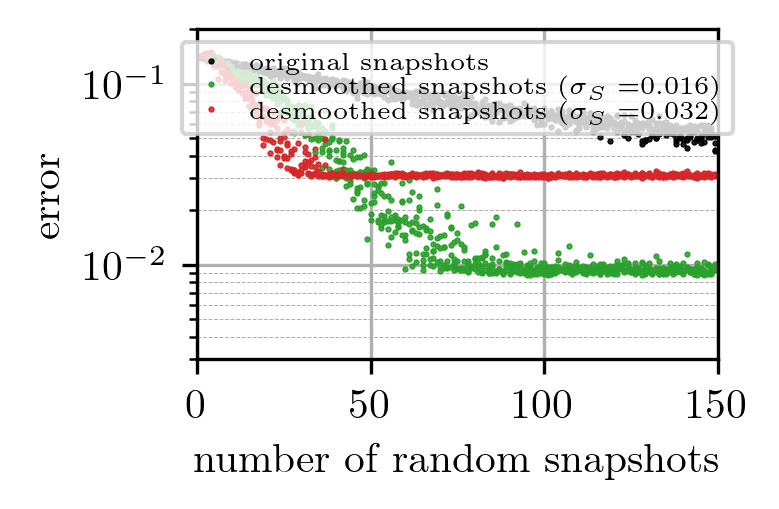

In [9]:
for name in ["random_smooth_data_fixed_sigma", "random_smooth_data_desmoothed_fixed_sigma"]:

    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    ax.plot(0, 1, "k.", ms=1, label="original snapshots")
    if name == "random_smooth_data_fixed_sigma":
        ax.plot(0, 1, "C0.", ms=1, label=r"smoothed snapshots ($\sigma_S=${:.3f})".format(_sima_))
        ax.plot(0, 1, "C1.", ms=1, label=r"smoothed snapshots ($\sigma_S=${:.3f})".format(_sima2_))
        ymin=1e-2
    if name == "random_smooth_data_desmoothed_fixed_sigma":
        ax.plot(0, 1, "C2.", ms=1, label=r"desmoothed snapshots ($\sigma_S=${:.3f})".format(_sima_))
        ax.plot(0, 1, "C3.", ms=1, label=r"desmoothed snapshots ($\sigma_S=${:.3f})".format(_sima2_))
        ymin=3e-3
    
    for trial in range(n_trials):
        ax.plot(NN, e_conventional[:, trial], "k.", ms=1)
        if name == "random_smooth_data_fixed_sigma":
            ax.plot(NN, e_smooth1[:, trial], "C0.", ms=1)
            ax.plot(NN, e_smooth2[:, trial], "C1.", ms=1)
        if name == "random_smooth_data_desmoothed_fixed_sigma":
            ax.plot(NN, e_desmoothed1[:, trial], "C2.", ms=1)
            ax.plot(NN, e_desmoothed2[:, trial], "C3.", ms=1)
    
    ax.grid()
    #ax.set_xscale('log')
    ax.set_yscale('log')
    #ax.set_yticks([*np.linspace(.01, .1, 10, endpoint=True), *np.linspace(.1, 1, 10, endpoint=True)], minor=True)
    #ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    #ax.grid(True, which='both')
    ax.set_ylim([ymin, 0.2])
    ax.set_xlim([0, 150])
    #ax.set_xlim([10, 100])
    #ax.set_xticklabels(["", "10", "20", "30", "", "50", "", "", "", "", "100"], minor=True)
    ax.set_xlabel("number of random snapshots")
    ax.set_ylabel("error")
    if name == "random_smooth_data_fixed_sigma":
        plt.legend(loc='lower center')
    if name == "random_smooth_data_desmoothed_fixed_sigma":
        plt.legend(loc='upper center')
        
    plt.savefig(pth+name+".pdf") # random_smooth_data_fixed_sigma, random_smooth_data_desmoothed_fixed_sigma
    plt.show()


# ROM

In [10]:
n_x = 3000
x = np.linspace(0, 1, n_x, endpoint=False)

n_test =  100
mu_test = np.linspace(0, 1, n_test)[:, None]

def narrow(x, mu):
    return rectangular_pulse(x, mu, w=0.02  + 1e-6)

case["n_x"] = n_x
case["shape"] = (n_x,)
case["x"] = x
case["num_iter"] = 100
case["sROM_only"] = False
case["g"] = narrow

In [11]:
case["num_iter"]

100

In [12]:
X = snapshots_rowwise(case["g"], x, mu=np.linspace(0, 1, n_x, endpoint=False))
U, S, VT = np.linalg.svd(X.T, full_matrices=False)
a, b = X.shape

delta_n = (np.cumsum(S[::-1]**2)[::-1]/a/b)**.5
dN = delta_n


3
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.06400000, 2.00000000, 0.17546061, 0.13935851, 0.15239295, -13.1469
0.5508628979934362 0.60238604314672
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.03200000, 2.00000000, 0.17546061, 0.14261305, 0.16968258, -3.2931
0.7972311733166394 0.9485544447309469
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.01600000, 2.00000000, 0.17546061, 0.14921509, 0.18286234, 4.2185
1.1796488248568773 1.4456537183098936
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.00800000, 2.00000000, 0.17546061, 0.15879190, 0.18744363, 6.8295
1.7753474152534068 2.0956835442358637
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 100, 0.00400000, 2.00000000, 0.17546061, 0.16695466, 0.18

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_234192\35921147.py:49: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


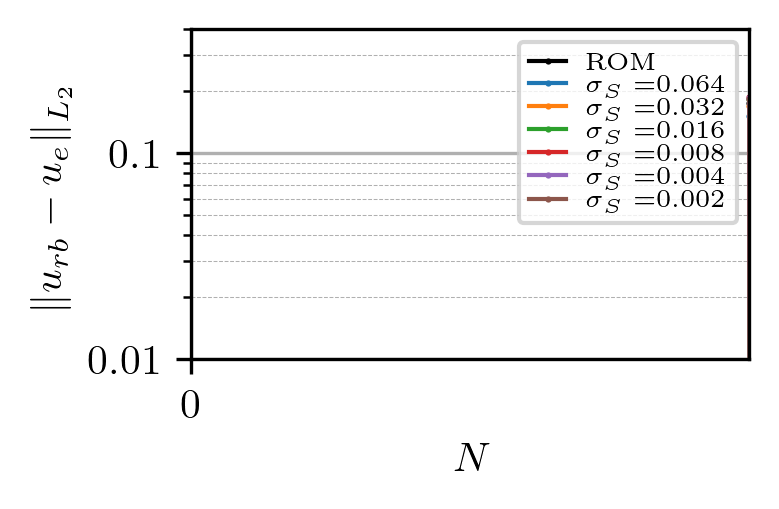

5


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.06400000, 2.00000000, 0.17020695, 0.13606694, 0.12622483, -25.8404
0.5378518216700999 0.49894744435364746
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.03200000, 2.00000000, 0.17020695, 0.13792835, 0.16372826, -3.8064
0.7710429162054246 0.9152688057225931
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.01600000, 2.00000000, 0.17020695, 0.14389442, 0.17766654, 4.3827
1.1375852892466567 1.4045773100962013
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.00800000, 2.00000000, 0.17020695, 0.15317277, 0.18233660, 7.1264
1.712523575320629 2.03858514156302
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 5, 100, 0.00400000, 2.00000000, 0.17020695, 0.16132292, 0.1815

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_234192\35921147.py:49: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


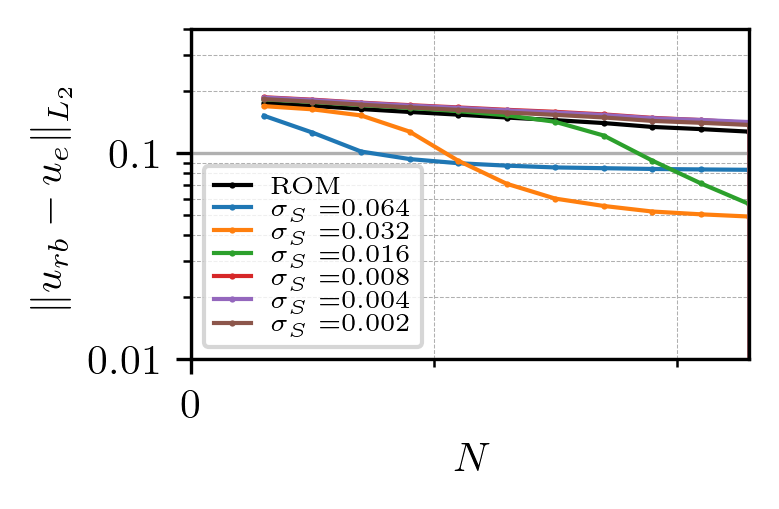

25


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.06400000, 2.00000000, 0.12270349, 0.13013807, 0.08251316, -32.7540
0.514415894584151 0.3261618954186271
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.03200000, 2.00000000, 0.12270349, 0.12029297, 0.04778223, -61.0588
0.6724581360408788 0.2671107804387884
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.01600000, 2.00000000, 0.12270349, 0.10942807, 0.04555154, -62.8767
0.8651048499485927 0.36011653613889677
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.00800000, 2.00000000, 0.12270349, 0.10735854, 0.13403032, 9.2311
1.200304976168515 1.498504580054875
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 25, 100, 0.00400000, 2.00000000, 0.12270349, 0.11237951

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_234192\35921147.py:49: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


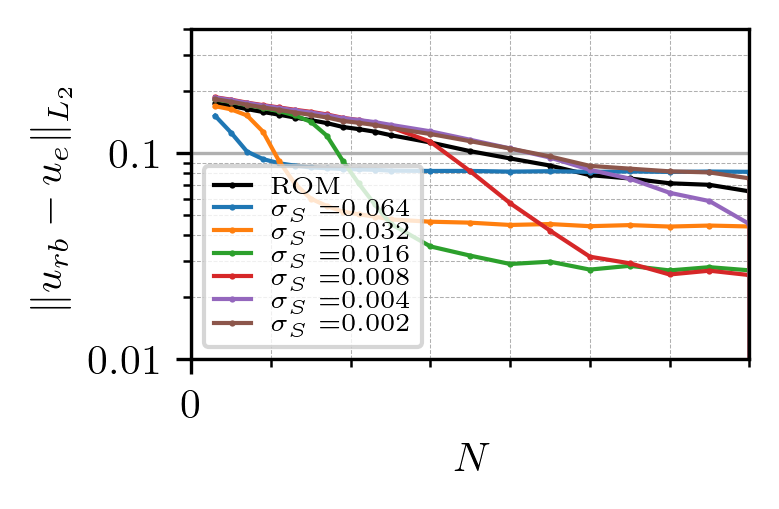

80


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.06400000, 2.00000000, 0.06190825, 0.12976958, 0.08136744, 31.4323
0.5129592997132293 0.32163305655285984
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.03200000, 2.00000000, 0.06190825, 0.11782448, 0.04404957, -28.8470
0.6586588681672301 0.24624460946977925
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.01600000, 2.00000000, 0.06190825, 0.09642267, 0.02674523, -56.7986
0.7622881571018834 0.21143962752023623
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.00800000, 2.00000000, 0.06190825, 0.07093002, 0.02596108, -58.0652
0.7930217442303134 0.29025370337170114
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 80, 100, 0.00400000, 2.00000000, 0.06190825, 0.0

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_234192\35921147.py:49: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


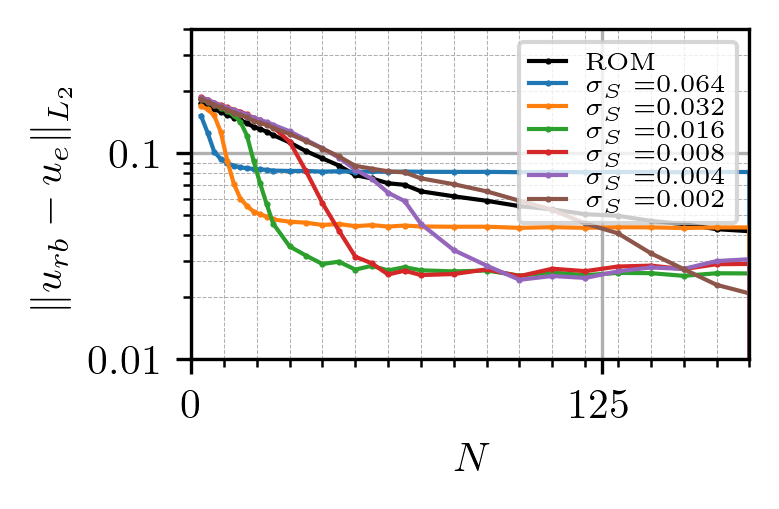

180


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.06400000, 2.00000000, 0.04063758, 0.12977720, 0.08125724, 99.9559
0.5129894241271497 0.32119742667326123
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.03200000, 2.00000000, 0.04063758, 0.11760830, 0.04376414, 7.6938
0.6574503995000295 0.24464895391486427
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.01600000, 2.00000000, 0.04063758, 0.09478611, 0.02634361, -35.1743
0.749349998779542 0.20826452933846304
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.00800000, 2.00000000, 0.04063758, 0.06491459, 0.02963288, -27.0801
0.7257671296108269 0.33130565075128376
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 180, 100, 0.00400000, 2.00000000, 0.04063758, 0

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_234192\35921147.py:49: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


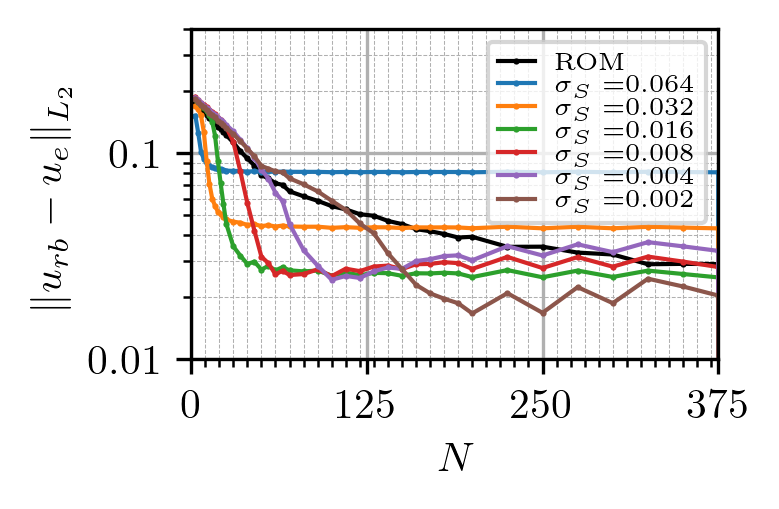

400


C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.06400000, 2.00000000, 0.02747530, 0.12963628, 0.08120823, 195.5681
0.5124323760539491 0.32100370894379693
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.03200000, 2.00000000, 0.02747530, 0.11745609, 0.04362822, 58.7907
0.6565995109854834 0.24388917631191098
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.01600000, 2.00000000, 0.02747530, 0.09440637, 0.02596041, -5.5136
0.746347911171939 0.20523509754434952
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.00800000, 2.00000000, 0.02747530, 0.06368885, 0.02989783, 8.8171
0.7120630238563952 0.3342679238083307
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 400, 100, 0.00400000, 2.00000000, 0.02747530, 0.0

In [13]:
NN_ROM = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
#NN = np.array([3, *np.arange(10, 200, 20), *np.arange(200, 525, 25)])
#NN = np.array([500])  # np.array([100, 150, 250, 350, 500])
#NN = np.array([3, 50, 100, 250, 500])
#NN = np.array([*np.arange(10, 30, 2), 50, 100, 200, 300, 400, 500])
dN_ROM = np.zeros(len(NN_ROM))
dN_ROMi = np.zeros(len(NN_ROM))

sig = [0.0025, 0.01]
sig = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
sig = np.array([0.064, 0.032, 0.016, 0.008, 0.004, 0.002])
#sig = np.array([0.032, 0.008])
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]

dN_sig_sROM = np.zeros((len(NN_ROM), len(sig)))
dN_sig_dsROM = np.zeros((len(NN_ROM), len(sig)))
for i, rank in enumerate(NN_ROM):
    n_train = rank
    print(rank)
    case["rank"] = rank
    case["n_train"] = n_train
    

    # case["mu_test"] = mu_test.copy()
    # in_range = mu_test[:, 0] < 1-1/rank
    # case["mu_test"] = case["mu_test"][in_range, :]
    s = rank//2
    case["mu_test"] = np.linspace(s/rank, (s+1)/rank, n_test, endpoint=False)[:, None]
    
    basis = U[:, :rank]
    X_test, _ = get_data_rw(mu_test, **case)
    X_test_ROMi = (basis @ (basis.T @ X_test.T)).T
    e_ROMi = L2_error_rw(X_test_ROMi, X_test)
    mean_ROMi = np.mean(e_ROMi)
    dN_ROMi[i] = mean_ROMi


    for j in range(len(sig)):
        case["sigma"] = sig[j]
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        dN_sig_sROM[i, j] = mean_sROM
        dN_sig_dsROM[i, j] = mean_sROMs
        print(mean_sROM/sig[j]**.5, mean_sROMs/sig[j]**.5)
        
    dN_ROM[i] = mean_ROM
    if i % 10 == 0:
        fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))

        plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
        #plt.plot(NN_ROM, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
        for j in range(len(sig)):
            plt.plot(NN_ROM, dN_sig_dsROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
        #plt.plot(NN_ROM, .4/NN_ROM**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
        plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
        plt.xlabel(r"$N$")
        plt.legend()
        ax.set_yscale("log")
        plt.xlim(0, rank)
        plt.ylim(0.02, 0.2)
        ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
        ax.set_xticks([0, 125, 250, 375, 500], minor=False)
        ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
        ax.set_yticks([0.1, 0.01], minor=False)
        #ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
        plt.grid(True, which="minor", linestyle="--", lw=0.25)
        plt.grid(True, which="major", linestyle="-")
        ax.set_yticklabels(["0.1", "0.01"], minor=False)
        plt.xlim(0, rank)
        
        plt.show()

np.save(pth+"/NN_ROM.npy", NN_ROM)
np.save(pth+"/dN_ROM.npy", dN_ROM)
np.save(pth+"/dN_ROMi.npy", dN_ROMi)
np.save(pth+"/dN_sig_sROM.npy", dN_sig_sROM)
np.save(pth+"/dN_sig_dsROM.npy", dN_sig_dsROM)
# np.save(pth+"/e_smooth2.npy", e_smooth2)
# np.save(pth+"/e_desmoothed1.npy", e_desmoothed1)
# np.save(pth+"/e_desmoothed2.npy", e_desmoothed2)

In [14]:
NN_ROM = np.load(pth+"/NN_ROM.npy")
dN_ROM = np.load(pth+"/dN_ROM.npy")
dN_ROMi = np.load(pth+"/dN_ROMi.npy")
dN_sig_sROM = np.load(pth+"/dN_sig_sROM.npy")
dN_sig_dsROM = np.load(pth+"/dN_sig_dsROM.npy")
NN_ROM.shape, dN_ROM.shape, dN_sig_sROM.shape, dN_sig_dsROM.shape

((45,), (45,), (45, 6), (45, 6))

In [15]:
plateauS = dN_sig_sROM[i]
plateauDS = dN_sig_dsROM[i]
#  $\sS$        & 0.064 & 0.032 & 0.016 & 0.008 & 0.004 & 0.002\\
# plateau S-ROM  & 0.096 & 0.092 & 0.083 & 0.067 & 0.045 & 0.032\\
# plateau DS-ROM & 0.074 & 0.044 & 0.024 & 0.016 & 0.02  & 0.018\\
# C (S-ROM)      & 0.379 & 0.513 & 0.657 & 0.748 & 0.719 & 0.712\\
# C (DS-ROM)     & 0.293 & 0.246 & 0.191 & 0.184 & 0.321 & 0.409\\
print(r"$\sS$         ", *np.round(sig, decimals=3), sep=" & ", end="\\\\\n")
print(r"plateau S-ROM ", *np.round(plateauS, decimals=3), sep=" & ", end="\\\\\n")
print(r"plateau DS-ROM", *np.round(plateauDS, decimals=3), sep=" & ", end="\\\\\n")
print(r"C (S-ROM)     ", *np.round(plateauS/np.array(sig)**.5, decimals=3), sep=" & ", end="\\\\\n")
print(r"C (DS-ROM)    ", *np.round(plateauDS/np.array(sig)**.5, decimals=3), sep=" & ", end="\\\\\n")

$\sS$          & 0.064 & 0.032 & 0.016 & 0.008 & 0.004 & 0.002\\
plateau S-ROM  & 0.13 & 0.118 & 0.095 & 0.064 & 0.044 & 0.032\\
plateau DS-ROM & 0.081 & 0.044 & 0.027 & 0.032 & 0.038 & 0.027\\
C (S-ROM)      & 0.513 & 0.657 & 0.747 & 0.713 & 0.693 & 0.721\\
C (DS-ROM)     & 0.322 & 0.246 & 0.213 & 0.355 & 0.596 & 0.598\\


C:\Users\florianma\AppData\Local\Temp\10\ipykernel_234192\1559596643.py:6: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


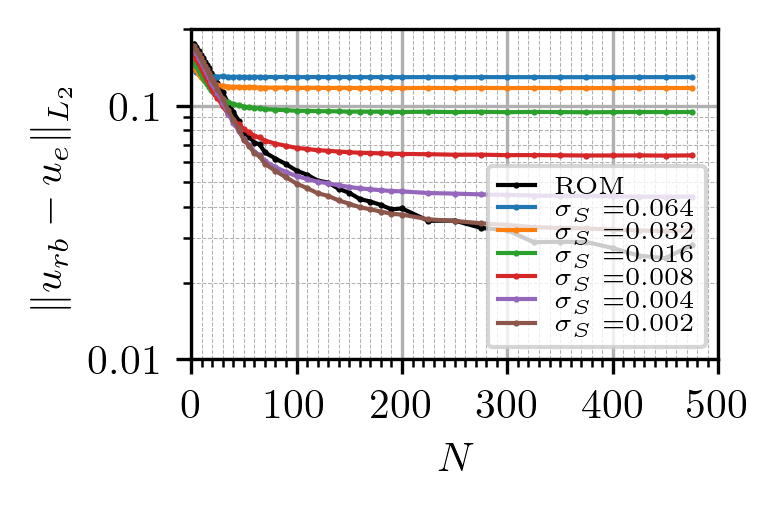

C:\Users\florianma\AppData\Local\Temp\10\ipykernel_234192\1559596643.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "k." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")


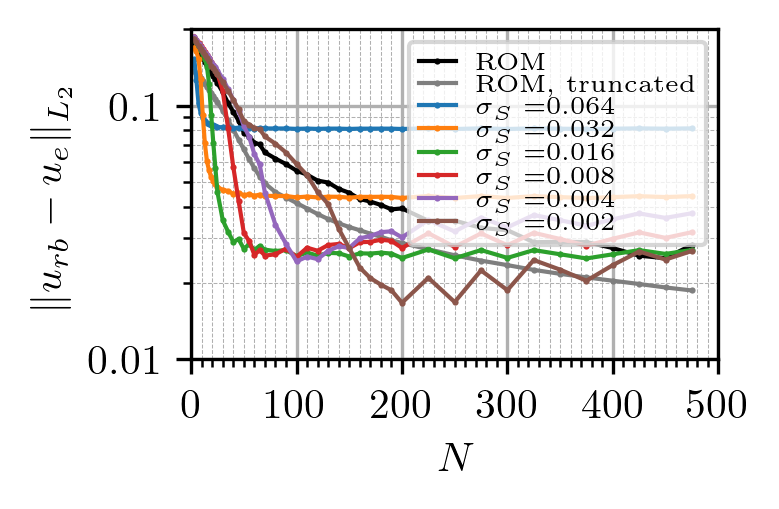

In [16]:
# N = np.arange(len(dN))
# decay_estimate = .5/N**.5


fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
# plt.plot(NN, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
#plt.plot(N, decay_estimate, "g.-", ms=2, label=r"decay estimate")
for j in range(len(sig)):
    plt.plot(NN_ROM, dN_sig_sROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.02, 0.2)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 100, 200, 300, 400, 500], minor=False)
ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
ax.set_yticks([0.1, 0.01], minor=False)
#ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1", "0.01"], minor=False)
plt.xlim(0, 500)
plt.ylim(0.01, 0.2)
plt.savefig(pth+"SROM_fixed_sig.pdf")
plt.show()

fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN_ROM, dN_ROM, "k.", ls="-", marker=".", lw=1, ms=1, label=r"ROM")
plt.plot(NN_ROM, dN_ROMi, "C7", ls="-", marker=".", lw=1, ms=1, label=r"ROM, truncated")
#plt.plot(N, decay_estimate, "g.-", ms=2, label=r"decay estimate")
for j in range(len(sig)):
    plt.plot(NN_ROM, dN_sig_dsROM[:, j], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+str(sig[j]))
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")
plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
plt.legend()
ax.set_yscale("log")
plt.xlim(0, 500)
plt.ylim(0.07, 0.2)
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_xticks([0, 100, 200, 300, 400, 500], minor=False)
ax.set_yticks([*np.linspace(0.01, 0.1, 10, endpoint=True), 0.2, 0.3, 0.4], minor=True)
ax.set_yticks([0.1, 0.01], minor=False)
#ax.set_yticklabels(["0.01"," ", "0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_yticklabels(["0.1", "0.01"], minor=False)
plt.xlim(0, 500)
plt.ylim(0.01, 0.2)
plt.savefig(pth+"DSROM_fixed_sig.pdf")
plt.show()

# random test data, 250 iter, w=0.1
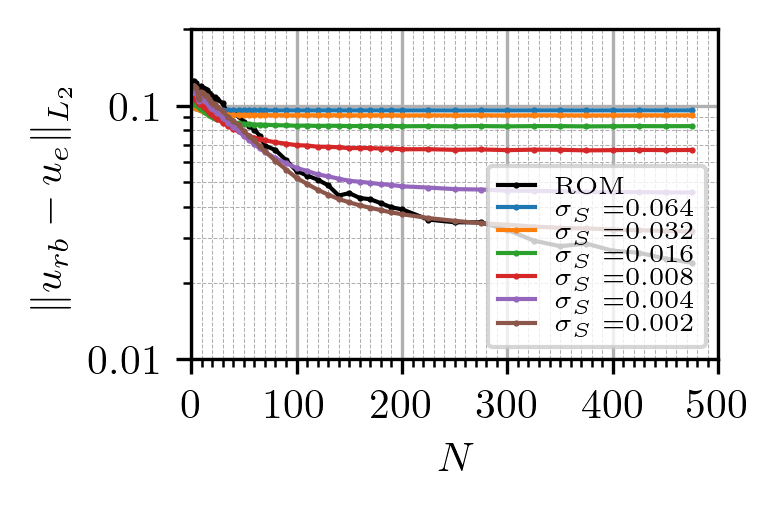

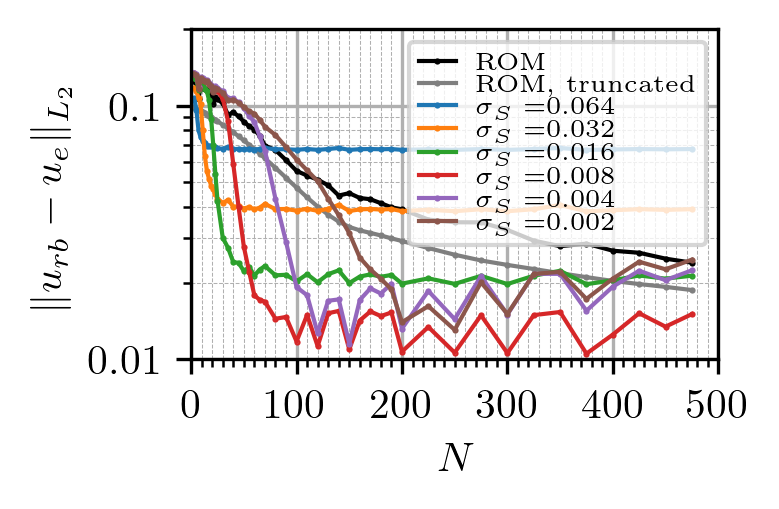

In [17]:
g = case["g"]

shape = case["shape"]
num_iter1 = 100
num_iter2 = 250

#def estimate_dN():

# num_iter = 200
#NN = np.array([*np.arange(4, 30, 2), *np.arange(30, 150, 10)])
NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
dN_ROM = np.zeros(len(NN))
dN_sig = np.zeros((len(NN), 10))

sig_N = np.zeros((len(NN), 10))
sig_N[:, 1] = .05/NN**.5
sig_N[:, 2] = .01/NN**.5
sig_N[:, 3] = .001/NN**.5
#sig_N[:, 3] = .4 / (NN)
sig_N[:, 4] = .3 / (NN)
sig_N[:, 5] = .2 / (NN)   # this is the one for narrow saw tooth
sig_N[:, 6] = .1 / (NN)
sig_N[:, 7] = 10 / (NN**2)
sig_N[:, 8] = 25 / (NN**2)
sig_N[:, 9] = 40 / (NN**2)
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]

for i, rank in enumerate(NN):
    n_train = rank
    print(rank)
    case["num_iter"] = num_iter1
    case["rank"] = rank
    case["n_train"] = n_train
    case["sROM_only"] = True
    
    case["mu_test"] = mu_test.copy()
    in_range = mu_test[:, 0] < 1-1/rank
    case["mu_test"] = case["mu_test"][in_range, :]
    
    parameters = optimize_sROM(case)
    sig_N[i, 0] = parameters[0]
    #sig_N[i, 0] = 0.02995521

    #for sigS, dN in zip([sig_opt, sig_1, sig_2, sig_3, sig_4], [dN_sig_opt, dN_sig_1, dN_sig_2, dN_sig_3, dN_sig_4]):
    for j in range(10):
        case["sigma"] = sig_N[i, j]
        mean_ROM, mean_sROM, mean_sROMs = target_function(case)
        dN_sig[i, j] = mean_sROM
        
    dN_ROM[i] = mean_ROM
np.save(pth+"8_dN_ROM.npy", dN_ROM)
np.save(pth+"8_dN_sig.npy", dN_sig)
np.save(pth+"8_sig_N.npy", sig_N)
np.save(pth+"8_NN.npy", NN)

3
max: 0.06666666666666667
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 66, 0.03333833, -, 0.17345515, 0.14131916, -, -18.5270
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 66, 0.05555722, -, 0.17345515, 0.13875223, -, -20.0069
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 66, 0.01111944, -, 0.17345515, 0.15312275, -, -11.7220
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 66, 0.06296352, -, 0.17345515, 0.13835757, -, -20.2344
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 66, 0.04815093, -, 0.17345515, 0.13931090, -, -19.6848
num_iter, n_train, n_test, sigma_S, sigma_D/c, mean_ROM, mean_sROM, mean_sROMs, improvement
100, 3, 66, 0.04074463, -, 0.17345515, 0.14011607, -, -19.2206
num_iter, n_train, n_test, sigma_S, sigma_D

In [18]:
dN_ROM = np.load(pth+"8_dN_ROM.npy")
dN_sig = np.load(pth+"8_dN_sig.npy")
sig_N = np.load(pth+"8_sig_N.npy")
NN = np.load(pth+"8_NN.npy")

[0.03 0.04 0.05 0.06 0.07 0.08 0.09]
[0.1]
[Text(0, 0.03, '0.03'), Text(0, 0.04, ' '), Text(0, 0.05, '0.05'), Text(0, 0.06, ' '), Text(0, 0.07, '0.07'), Text(0, 0.08, ' '), Text(0, 0.09, ' ')]


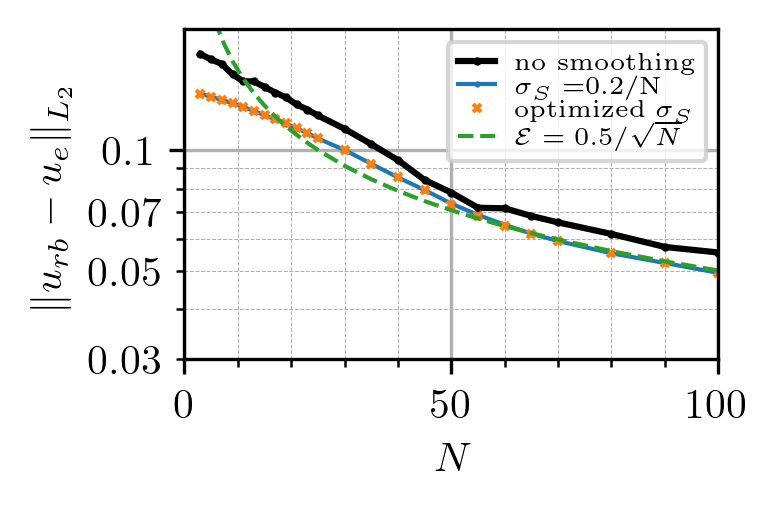

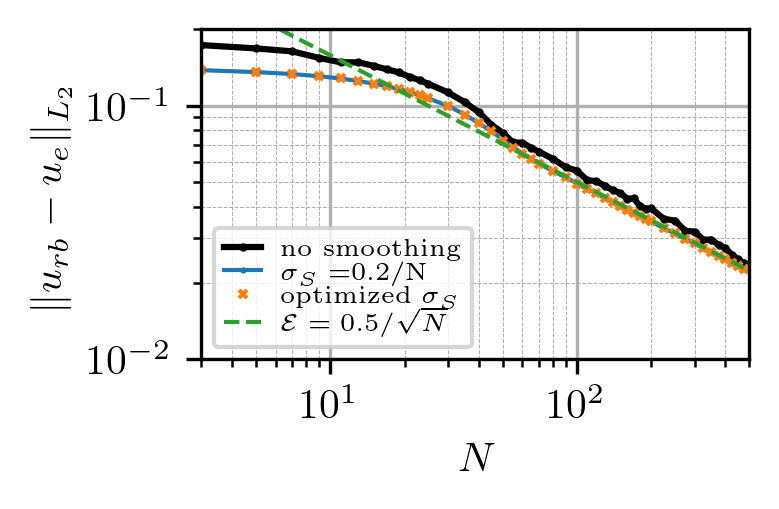

In [19]:
fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
#plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_ROM, "k.-", ms=2, label=r"no smoothing")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
#plt.plot(NN, np.exp(-NN/300)/12, "C3--", lw=1, ms=1, label=r"$exp(-N)$")
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
#plt.plot(NN, .4/NN**.5, "C2--", lw=1, ms=1, label=r"$0.4/\sqrt{N}$")  # saw tooth w=1/45
plt.plot(NN, .5/NN**.5, "C2--", lw=1, ms=1, label=r"$\mathcal{E}=0.5/\sqrt{N}$")  # rect pulse w=0.2

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()


ax.set_yscale("log")
plt.xlim(0, 100)
plt.ylim(0.03, 0.2)


ax.set_xticks(np.linspace(0, 100, 11, endpoint=True), minor=True)
ax.set_xticks([0, 50, 100], minor=False)

ax.set_yticks(np.linspace(0.03, 0.1, 8, endpoint=True), minor=True)
ax.set_yticks([0.1], minor=False)
ax.set_yticklabels(["0.03"," ", "0.05", " ", "0.07", " ", " ", "0.1" ], minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
# ax.set_yticks([0.03, 0.05, 0.06, 0.1], minor=False)
#ax.set_yticklabels(["0.03", "0.04", "0.06", "0.1"], minor=True)
ax.set_yticklabels(["0.1"], minor=False)




#ax.set_yticks(np.linspace(0.01, 0.1, 10, endpoint=True), minor=True)
#ax.set_yticklabels(["0.01", "0.1" ], minor=False)
#ax.set_yticklabels(["0.01", "0.02", "0.03"," 0.04", "0.05", "0.06", "0.07", "0.08", "0.09", "0.1" ], minor=True)
print(ax.get_yticks(minor=True))
print(ax.get_yticks(minor=False))
print(ax.get_yticklabels(minor=True))

# fmt = lambda x, pos: '{:.2f}'.format(x, pos)
# ax.yaxis.set_minor_formatter(mpl.ticker.FuncFormatter(fmt))
# ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(fmt))
plt.savefig(pth+"SROM_sig_is_fun_of_N_preasympt.pdf")
plt.show()






fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.-", ms=2, label="no smoothing")
# for i in [2, 5, 7]: #range(4, 10):
#     plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
#plt.plot(NN, dN_sig[:, 2], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[2])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 5], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[5])# r"$u_{\mu,Srb}$"
#plt.plot(NN, dN_sig[:, 7], ls="-", marker=".", lw=1, ms=1, label=r"$\sigma_S=$"+lbls[7])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
plt.plot(NN, .5/NN**.5, "C2--", lw=1, ms=1, label=r"$\mathcal{E}=0.5/\sqrt{N}$")# r"$u_{\mu,Srb}$"

plt.ylabel(r"$\|u_{rb}-u_{e}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_xscale("log")
ax.set_yscale("log")
plt.xlim(3, 500)
plt.ylim(1e-2, 0.2)
plt.savefig(pth+"SROM_sig_is_fun_of_N_asympt.pdf")
plt.show()

Text(0, 0.5, '$\\sigma_S$')

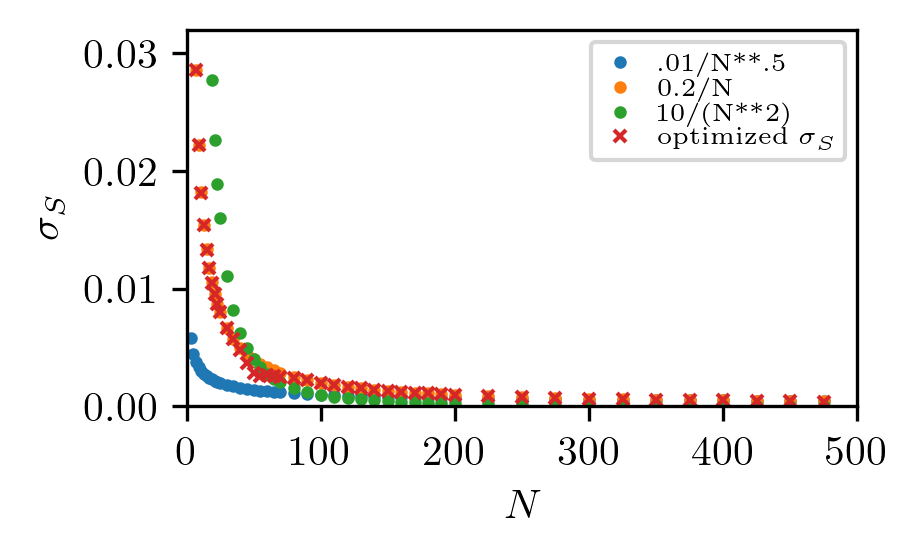

In [21]:
for i in [2, 5, 7]: #range(4, 10):
    plt.plot(NN, sig_N[:, i], "o", ms=2, label=lbls[i])
plt.plot(NN, sig_N[:, 0], "x", ms=3, label=r"optimized $\sigma_S$")
plt.legend()
plt.xlim(0, 500)
plt.ylim(0, 0.032)
plt.xlabel("$N$")
plt.ylabel(r"$\sigma_S$")